# ATF Case: LWIR Laser–Plasma Interaction

This notebook analyzes an ATF-relevant laser–plasma case with parameters corresponding to a long-wavelength infrared driver:

$$
n_e = 2 \times 10^{16}\ \mathrm{cm^{-3}},
\quad \lambda_0 = 9.2\ \mu\mathrm{m},
\quad w_0 = 75\ \mu\mathrm{m},
\quad a_0 = 3.26,
\quad \tau_{FWHM} = 500\ \mathrm{fs}.
$$

In normalized plasma units, these parameters correspond to

$$
k_p w_0 = 1.99,
\quad k_p c \tau = 3.98.
$$

This case represents an upgraded ATF-like operating point for a CO\(_2\)-laser-driven plasma wakefield interaction. 

This notebook calculates and visualizes a **single-electron trajectory** in the wakefield generated by this ATF parameter set. It is intended as a lightweight case for inspecting the fields, forces, and particle motion for one representative test electron. Multi-electron trajectory tracking with multi-core processing on a personal computer is available in the `ATF2e16_multi-processing` notebook in the same folder.

In [9]:
from pathlib import Path
import os
import sys

core_name = "ZEUS_1p6e17"

project_root = Path.cwd().resolve()

while not (project_root / "main.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Could not find QuEP project root containing main.py.")
    project_root = project_root.parent

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Working directory set to:", project_root)

Working directory set to: /Users/navidv/GitHub/QuEP


In [10]:
# This cell creates a Python input file in the subfolder input/.

input_text = f"""
# Auto-generated by {core_name}_single_track notebook.

simulation_name = "QUASI3D"

shape = "single"

iterations = 15000

# mode 0 is the wakefield, mode 1 is the laser, mode -1 is both.
mode = -1

fname = "{core_name}.npz"

debugmode = True

# Probe centered at the following initial coordinates, in c/omega_p.
x_c = 0
y_c = 0.5
xi_c = 2

# Initial momentum.
px_0 = 110
py_0 = 0
pz_0 = 0

# Screen distances from z-axis of plasma cell, in mm.
x_s = [10, 50, 100, 250, 500]

# Shape parameters.
s1 = 1  # in y
s2 = 1  # in xi

# Densities.
ydensity = 1
xidensity = 1
xdensity = 1
resolution = None

# Quasi3D simulation parameters.
quasi_id = "000074"
quasi_data_dir = "data/OSIRIS/BELLA_PW/BELLA_PW_ne-1p6e17_a0-2p7"
quasi_density = 1.6e23
quasi_propagation_speed = 1.0
dt_safety_factor = 0.45 #dt=dz*(safetyfactor <= 0.5)
"""

input_path = project_root / "input" / f"{core_name}.py"
input_path.write_text(input_text.strip() + "\n")

print(f"Wrote {input_path}")

Wrote /Users/navidv/GitHub/QuEP/input/ZEUS_1p6e17.py


In [12]:
#Run first cell to change into the project root directory
%reset -f
%run main.py input.ZEUS_1p6e17

Start Time:  16:42:21
Using initial conditions from  input.ZEUS_1p6e17


OSError: Unable to synchronously open file (file signature not found)

In [9]:
#This cell is intended to be able to load everything independently.
#so you need to enter the core_name again
%reset -f

core_name = "ATF2e16"

import gc
import importlib
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Clean up memory from earlier notebook cells.
gc.collect()

# Make sure imports work when the notebook is run from the project root.
project_root = Path.cwd()
print("Working directory set to:", project_root)

# -----------------------------------------------------------------------------
# Load the user input file
# -----------------------------------------------------------------------------
# Use the module name, not the .py or .npz filename.
# For input/betatron_tutorial_input.py, use "input.betatron_tutorial_input" if
input_module = f"input.{core_name}"
init = importlib.import_module(input_module)

# -----------------------------------------------------------------------------
# Configure the Quasi3D field infrastructure
# -----------------------------------------------------------------------------
import include.simulations.useQuasi3D as sim
sim.configure(init)

# -----------------------------------------------------------------------------
# Load the debug trajectory object
# -----------------------------------------------------------------------------
debug_file = project_root / "data" / f"{core_name}-DEBUG.obj"

with open(debug_file, "rb") as file:
    debug_loaded = pickle.load(file)

# main.py saves Debug as a one-element list/tuple in this tutorial case.
debug = debug_loaded[0] if isinstance(debug_loaded, (list, tuple)) else debug_loaded

print(f"Loaded input module: {init.__name__}")
print(f"Loaded debug file:   {debug_file}")
print("\nThe Debug object contains the following saved simulation quantities:")
for key, value in debug.__dict__.items():
    print(f"{key:20s}  type={type(value).__name__:15s}  shape={np.shape(value)}")

Working directory set to: /Users/navidv/GitHub/QuEP
Using laser vector-potential region:
  xi range: -12.005749999999999 9.999749999999999
  index range: 0 3999
Loaded input module: input.ATF2e16
Loaded debug file:   /Users/navidv/GitHub/QuEP/data/ATF2e16-DEBUG.obj

The Debug object contains the following saved simulation quantities:
x_dat                 type=ndarray          shape=(1, 4017)
y_dat                 type=ndarray          shape=(1, 4017)
z_dat                 type=ndarray          shape=(1, 4017)
xi_dat                type=ndarray          shape=(1, 4017)
Fx_dat                type=ndarray          shape=(1, 4017)
Fy_dat                type=ndarray          shape=(1, 4017)
Fz_dat                type=ndarray          shape=(1, 4017)
px_dat                type=ndarray          shape=(1, 4017)
py_dat                type=ndarray          shape=(1, 4017)
pz_dat                type=ndarray          shape=(1, 4017)


In [15]:
#Defining functions that allows fields to be called as needed
def as_2d(arr):
    """Return an array with shape (n_particles, n_steps)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def get_r_xi_from_debug(debug):
    """Extract r and xi trajectory arrays from a DebugObject."""
    x_dat = as_2d(debug.x_dat)
    y_dat = as_2d(debug.y_dat)
    xi_dat = as_2d(debug.xi_dat)

    r_dat = np.sqrt(x_dat**2 + y_dat**2)
    return r_dat, xi_dat


def symmetric_color_limits(field, percentile=99):
    """Choose symmetric color limits using a percentile to avoid outlier domination."""
    vmax = np.nanpercentile(np.abs(field), percentile)
    return -vmax, vmax


def plot_field_with_debug_trajectories(
    xi_axis,
    r_axis,
    field,
    debug,
    *,
    title,
    field_label,
    xlim=None,
    ylim=None,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
):
    """Plot a Quasi3D field in (xi, r) and overlay debug trajectories."""
    r_dat, xi_dat = get_r_xi_from_debug(debug)

    if vmin is None or vmax is None:
        auto_vmin, auto_vmax = symmetric_color_limits(field)
        vmin = auto_vmin if vmin is None else vmin
        vmax = auto_vmax if vmax is None else vmax

    fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

    mesh = ax.pcolormesh(
        xi_axis,
        r_axis,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    for i in range(r_dat.shape[0]):
        ax.plot(
            xi_dat[i, :],
            r_dat[i, :],
            color="black",
            linewidth=1.5,
            label="debug trajectory" if i == 0 else None,
        )

    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")
    ax.set_ylabel(r"$r$ $(c/\omega_p)$")
    ax.set_title(title)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if r_dat.shape[0] > 0:
        ax.legend(loc="best")

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(field_label)

    fig.tight_layout()
    plt.show()


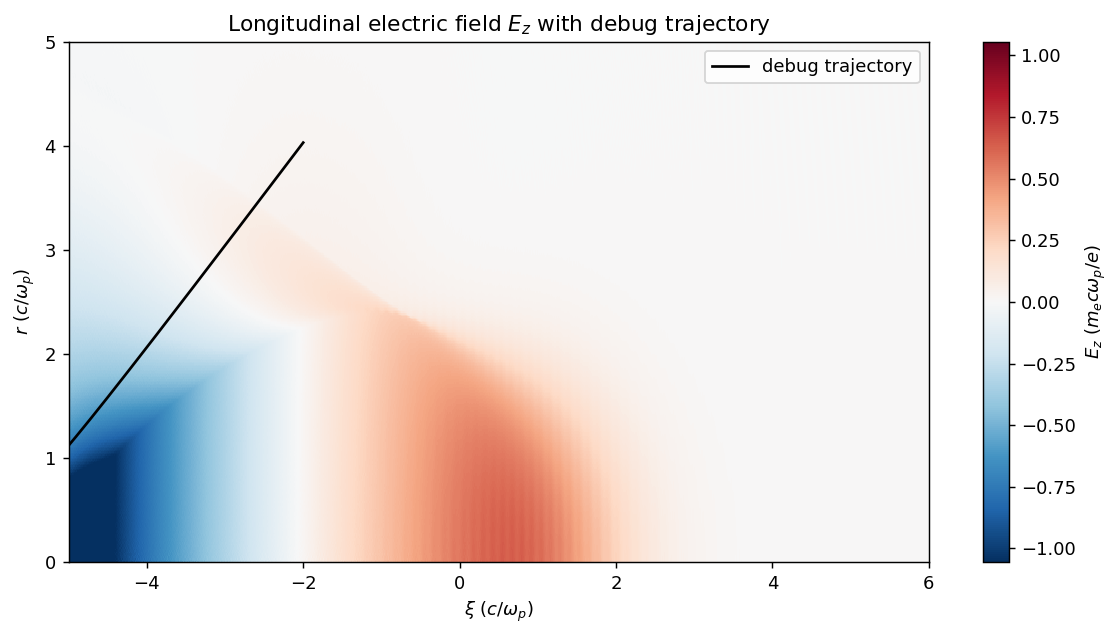

In [16]:
# Longitudinal electric field with the debug trajectory overlaid.
# E1_M0 lives on (xiaxis_1, raxis_2).
plot_field_with_debug_trajectories(
    sim.xiaxis_1,
    sim.raxis_2,
    sim.E1_M0,
    debug,
    title=r"Longitudinal electric field $E_z$ with debug trajectory",
    field_label=r"$E_z$ $(m_e c \omega_p/e)$",
    xlim=(-5, 6),
    # xlim=(1, 3),
    ylim=(0, 5),
    # vmin=0.5,
    # vmax=0.7
)